<a href="https://colab.research.google.com/github/ancalau13-web/analysis-landing_page-/blob/main/Proyecto_Landing_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [ ]:
# importar librerías
import pandas as pd
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
from scipy.stats import levene
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')

**Vista previa e información general del conjunto de datos**

In [ ]:
# mostrar las primeras 5 filas
df.head(5)


,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [ ]:
# información general
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


✍️ **Comentario**:
- Valores ausentes: El dataset no tiene valores ausentes. Todas las columnas cuentan con 40,000 registros de tipo non-null.
- La columna date es de tipo object (cadena de texto) y debería ser de tipo datetime64 para facilitar análisis temporales.
- Las columnas categóricas como landing, region, dispositivo, traffic_source y user_type son de tipo object y se podrían optimizar convirtiéndolas al tipo category.
- La columna converted es de tipo int64 (funciona para análisis numéricos, pero es una variable booleana, por lo que se puede transformar a bool o mantener como int64 para calcular tasas de conversión directamente)
- Si hay errores como valores nulos o columna con tipo de dato incorrecto, define pasos a seguir. Por ejemplo:


**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [ ]:
df["user_id"].duplicated().sum()

0

 **Variable `date`**  
Explorar rango de fechas

In [ ]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [ ]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [ ]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [ ]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"]==1]["gasto"]

0         38.08
9         27.61
17        42.97
25        70.59
27       119.26
          ...  
39967    141.21
39971     37.76
39973     49.17
39974     72.76
39999    120.37
Name: gasto, Length: 5706, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [ ]:

# Explorar variables categóricas y cómo se distribuyen
columnas_categoricas=["region", "dispositivo", "traffic_source" , "user_type"]
for col in columnas_categoricas:
    print("\nConteo de categorías:")
    print (df[col].value_counts())



Conteo de categorías:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Conteo de categorías:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Conteo de categorías:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Conteo de categorías:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


- Todas las columnas tienen valores esperados. No se observan errores de formato, valores negativos ni categorías mal escritas o duplicadas (como faltas de ortografía o variaciones de mayúsculas/minúsculas).

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [ ]:

# Gasto por versión
conversion_total = df.groupby("landing")["converted"].sum()
df_A = df[(df["landing"]=="A")&(df["converted"]==1)]
gasto_A =df_A["gasto"].mean()
df_B = df[(df["landing"]=="B")&(df["converted"]==1)]
gasto_B =df_B["gasto"].mean()

# Verificar cantidad de datos que tiene cada grupo
print("Cantidad de conversiones por grupo:", len(df_A), len(df_B))
print("Gasto promedio por grupo:", gasto_A, gasto_B)


Cantidad de conversiones por grupo: 2512 3194
Gasto promedio por grupo: 61.0865724522293 68.74536005009392


In [ ]:
# Prueba de Levene
l_stat, p_value_var = levene(df_A["gasto"], df_B["gasto"])
print(f"Estadístico de Levene: {l_stat}")
print(f"Valor p: {p_value_var}")

Estadístico de Levene: 29.17646453202917
Valor p: 6.875301988016449e-08


In [ ]:
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia de varianzas diferentes (equal_var=True).")


Rechazamos la hipótesis nula: hay evidencia de varianzas diferentes (equal_var=False).


### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):**No hay diferencia entre el gasto promedio de A y B
- **Hipótesis alternativa (H₁):**Hay evidencia entre el gasto promedio de A y B

In [ ]:
# Aplicar prueba
t_start,p_value=ttest_ind(df_A["gasto"],df_B["gasto"],equal_var=False)


# Visualizar resultados
print(f"Estadístico : {t_start}")
print(f"Valor p: {p_value}")

Estadístico : -9.48101092267275
Valor p: 3.627602231521493e-21


In [ ]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")


Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Sí existen diferencias estadísticamente significativas en el gasto promedio de los clientes entre ambas páginas, siendo la Página B la que genera un valor económico significativamente mayor para el negocio.Explica con tus propias palabras qué indican estos resultados sobre el gasto promedio entre la página A y la página B.


---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen diferencias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):**No hay diferencia entre la tasa de conversion de la página A y B.
- **Hipótesis alternativa (H₁):** Existe diferencia entre la tasa de conversion de la página A y B.

In [ ]:
# Número de usuarios convertidos por página
conversiones=df.groupby("landing")["converted"].sum()

# Total de usuarios por página
totales=df.groupby("landing")["user_id"].count()


print("Usuarios convertidos por página:\n", conversiones)
print("\nTotal de usuarios por página:\n", totales)



Usuarios convertidos por página:
 landing
A    2512
B    3194
Name: converted, dtype: int64

Total de usuarios por página:
 landing
A    19982
B    20018
Name: user_id, dtype: int64


In [ ]:
#Validar tasa de conversión por página
tasa_conversion = conversiones/totales
print(tasa_conversion)

landing
A    0.125713
B    0.159556
dtype: float64


In [ ]:
# Aplicar prueba
z_stat,p_value=proportions_ztest(conversiones,totales)


# Visualizar resultados
print(f"Estadístico : {z_stat}")
print(f"Valor p: {p_value}")

Estadístico : -9.677362674655983
Valor p: 3.7629765627523803e-22


In [ ]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")


Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula y se acepta la hipótesis alternativa H1.

**Interpretación de negocio:**  
Existe una diferencia estadísticamente significativa en la tasa de conversión entre ambas versiones del sitio web, de igual forma de evidencia la página B convierte 3,39 pp más usuarios que la A.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay asociación estadísticamente significativa entre fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Existe asociación estadísticamente significativa entre fuente de tráfico y la conversión.

In [ ]:
# Aplicar prueba
tabla=pd.crosstab(df["traffic_source"],df["converted"],normalize="index")*100
print(tabla)

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


In [ ]:

tabla=pd.crosstab(df["traffic_source"],df["converted"])
print(tabla)


converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [ ]:
chi2_contingency(tabla)

Chi2ContingencyResult(statistic=8.662108841397938, pvalue=0.0341375947833914, dof=3, expected_freq=array([[10232.47225,  1702.52775],
       [ 5249.55405,   873.44595],
       [15421.15445,  2565.84555],
       [ 3390.81925,   564.18075]]))

In [ ]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia.")


Rechazamos la hipótesis nula: hay evidencia de una diferencia.


### 📝 Conclusión e interpretación

**Decisión:**  
Se rechaza la hipótesis nula.

**Interpretación de negocio:**  
Existe una asociación estadísticamente significativa entre traffic_source y converted. En otras palabras, la fuente de tráfico parece influir en si un usuario se convierte o no.


## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba ...

**Hipótesis:**
- **Hipótesis nula (H₀):** No hay asociación estadísticamente significativa entre fuente de tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe sociación estadísticamente significativa entre fuente de tipo de usuario y la conversión.

In [ ]:
# Aplicar prueba
tabla=pd.crosstab(df["user_type"],df["converted"])
print(tabla)




converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [ ]:
chi2_contingency(tabla)

Chi2ContingencyResult(statistic=0.5134849494478645, pvalue=0.4736341272301974, dof=1, expected_freq=array([[22319.39255,  3713.60745],
       [11974.60745,  1992.39255]]))

In [ ]:
# Interpretar resultados
alpha = 0.05  # umbral de significancia
if p_value > alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una asociación.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una asociación.")


No rechazamos la hipótesis nula: no hay evidencia suficiente de una asociación.


### 📝 Conclusión e interpretación

**Decisión:**  
No se rechaza la hipótesis nula.

**Interpretación de negocio:**  
No existe una asociación estadísticamente significativa entre el tipo de usuario (user_type: Nuevo vs. Recurrente) y la probabilidad de conversión (converted). La variación observada en los datos se debe completamente al azar. El hecho de que un usuario sea Nuevo o Recurrente no altera de forma relevante su propensión a convertirse en cliente durante la visita analizada. Ambos perfiles muestran probabilidades de conversión prácticamente equivalentes.

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

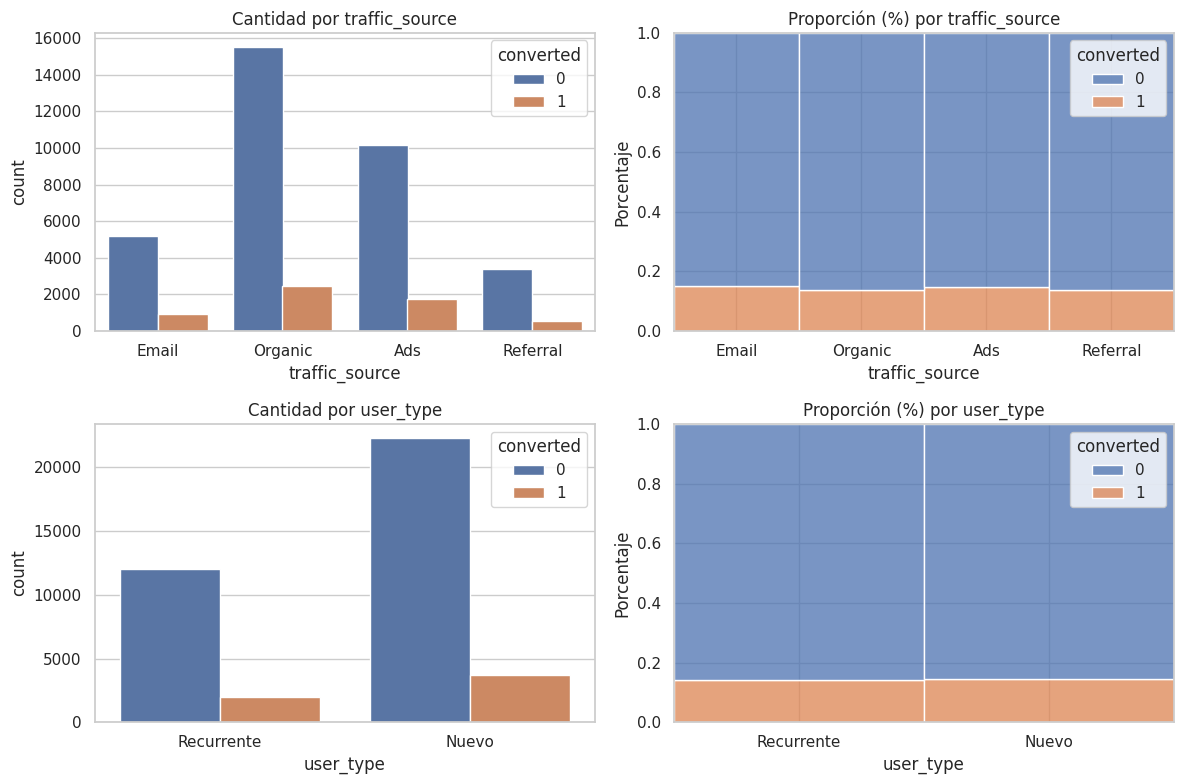

In [ ]:
cat_cols = ["traffic_source", "user_type"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(cat_cols):
    # 1. Cantidad absoluta
    sns.countplot(data=df, x=col, hue="converted", ax=axes[i, 0])
    axes[i, 0].set_title(f"Cantidad por {col}")

    # 2. Proporción (%)
    sns.histplot(
        data=df,
        x=col,
        hue="converted",
        multiple="fill",
        stat="probability",
        ax=axes[i, 1],
    )
    axes[i, 1].set_title(f"Proporción (%) por {col}")
    axes[i, 1].set_ylabel("Porcentaje")

plt.tight_layout()
plt.show()

### Relación entre la fuente de tráfico y la conversión

In [ ]:
- El canal Organic es el principal generador de tráfico y volumen de conversiones absolutas (con más de 2,000 conversiones), seguido de cerca por Ads.
Los canales Email y Referral aportan un volumen significativamente menor.
- La tasa de conversión se mantiene homogénea alrededor del 15% en todas las fuentes de tráfico (Email, Organic, Ads y Referral).
- Ningún canal de tráfico es inherentemente más eficiente que otro al convertir visitas; las diferencias en el número total de conversiones se deben
exclusivamente al volumen de tráfico recibido, no a la efectividad de la fuente.

### Relación entre el tipo de usuario y la conversión

In [ ]:
- Los usuarios de tipo Nuevo representan la gran mayoría del tráfico total e impulsan la mayor cantidad de conversiones en términos absolutos en
comparación con los usuarios Recurrentes.
- La proporción de conversión es idéntica (aproximadamente 15%) tanto para usuarios Nuevos como Recurrentes.
- Ser un usuario nuevo o recurrente no influye en la probabilidad individual de convertir.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?
  La Página B es la ganadora absoluta. Genera una tasa de conversión más alta (15.96% vs. 12.57%) y un mayor gasto promedio por conversión ($68.75 vs. $61.09).
  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?
  Email (14.99%) y Ads (14.74%) son los canales más efectivos para la conversión. Aunque el tráfico Orgánico atrae el mayor volumen total de usuarios (17,987), su tasa de conversión es la más baja (13.79%).

  
- ¿Existen diferencias significativas según el tipo de usuario?
  No. La condición de usuario Nuevo o Recurrente no influye de manera relevante en la probabilidad de conversión durante la sesión analizada.
  


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**
- El gasto promedio en la Página A es de $61.09 (sobre 2,512 conversiones).
- El gasto promedio en la Página B es de $68.75 (sobre 3,194 conversiones).
- **La Prueba t de muestras independientes arrojó un p-valor significativo, rechazando la hipótesis nula. Existe una diferencia estadísticamente significativa a favor de la Página B, la cual genera un valor económico por cliente convertible mayor en $7.66.**

<br>

**Tasa de conversión:**
- La tasa de conversión de la Página A es del 12.57% (2,512 convertidos de 19,982 usuarios).
- La tasa de conversión de la Página B es del 15.96% (3,194 convertidos de 20,018 usuarios).
- **La prueba Z de proporciones muestra un p-valor significativo, aceptando la hipótesis alternativa. La Página B incrementa la conversión en 3.39 puntos porcentuales respecto a la A.**

---

#### 📊 **Segmentación por fuente de tráfico**
- Las tasas de conversión por canal son: Email (14.99%), Ads (14.74%), Referral (13.88%) y Organic (13.79%).
- **La prueba de Chi-cuadrado arrojó un p-valor de 0.0341, lo que confirma una asociación estadísticamente significativa entre la fuente de tráfico y la probabilidad de conversión. Los canales directo/pago como Email y Ads muestran la mayor efectividad relativa para convertir usuarios.**

 ---

#### 📊 **Segmentación por tipo de usuario**
- Los usuarios Nuevos convirtieron al 14.36% (3,738 de 26,033) y los Recurrentes al 14.09% (1,968 de 13,967).
- **La prueba de Chi-cuadrado obtuvo un p-valor de 0.4736, por lo que no se rechaza la hipótesis nula. No existe una diferencia estadísticamente significativa entre usuarios Nuevos y Recurrentes; la variación observada es producto del azar y ambos perfiles muestran la misma propensión a convertir**

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:**
- Se sugiere Implementar y desplegar la Página B al 100% del tráfico: La versión B demostró superioridad tanto en volumen de conversiones como en monetización por usuario.
- Revisar para reasignar presupuesto de marketing hacia Email y Ads: Aumentar la inversión en captación a través de campañas de Email Marketing y Anuncios Pagados, dado su mejor desempeño relativo en conversión
- Optimizar el embudo de Tráfico Orgánico: Analizar el recorrido de los usuarios que provienen de búsquedas orgánicas para mejorar su tasa de conversión, aprovechando el alto volumen de tráfico que aporta este canal.